# Assignment 1: Feature Extraction and Deep Learning for Images
## Section 3: Transfer Learning

### Prasanna Paithankar (21CS30065)

4th February 2026

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2
)

100%|██████████| 170M/170M [00:16<00:00, 10.2MB/s]


In [3]:
resnet18 = torchvision.models.resnet18(weights="IMAGENET1K_V1")

for param in resnet18.parameters():
    param.requires_grad = False

num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 10)

resnet18 = resnet18.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001)

train_losses = []

for epoch in range(5):
    resnet18.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet18(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch + 1}/5, Loss: {epoch_loss:.4f}")

Epoch 1/5, Loss: 0.9186
Epoch 2/5, Loss: 0.6979
Epoch 3/5, Loss: 0.6645
Epoch 4/5, Loss: 0.6509
Epoch 5/5, Loss: 0.6416


Test Accuracy: 78.28%


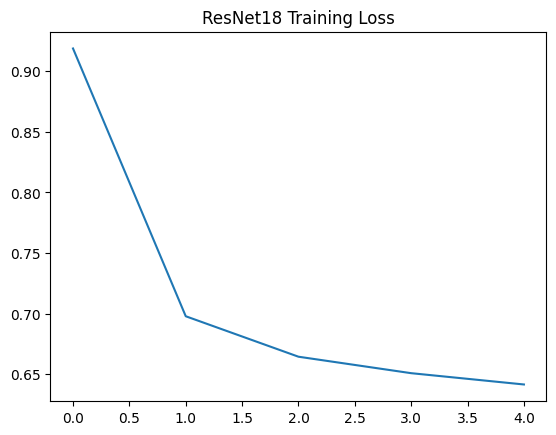

In [5]:
resnet18.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

plt.plot(train_losses)
plt.title("ResNet18 Training Loss")
plt.show()

#### Best Model in Section 2: (Loss: 0.0682 | Train Acc: 97.55% | Test Acc: 86.37%)

***